# Notebook 89 — full-sequence replay of notebook-only Hough patches

This notebook replays the notebook-only Hough patches that looked mathematically meaningful in notebook 88 on the full aligned sequence, while keeping the same per-frame binary fascicle masks fixed.

In [1]:
from pathlib import Path
import subprocess
import sys
from IPython.display import Markdown, Image, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'scripts').exists():
    ROOT = ROOT.parent
SCRIPT = ROOT / 'scripts' / 'evaluate_fullsequence_hough_patches.py'
OUT = ROOT / 'results' / 'notebook89_fullsequence_hough_patches'
print(f'Project root: {ROOT}')
print(f'Script: {SCRIPT}')
print(f'Output directory: {OUT}')

Project root: /Users/grosbedou/PycharmProjects/NDORMS
Script: /Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_fullsequence_hough_patches.py
Output directory: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook89_fullsequence_hough_patches


In [2]:
completed = subprocess.run([sys.executable, str(SCRIPT)], check=True)
completed

Loading cached baseline minimal geofeatures from /Users/grosbedou/PycharmProjects/NDORMS/results/notebook89_fullsequence_hough_patches/baseline_minimal_geofeatures.pkl
Evaluating full-sequence Hough patch variant: baseline_current
Evaluating full-sequence Hough patch variant: no_radius_correction
Evaluating full-sequence Hough patch variant: angle_profile_localmax
Evaluating full-sequence Hough patch variant: angle_profile_localmax_no_radius
# Notebook 89 — full-sequence replay of notebook-only Hough patches

Recomputed or loaded the full baseline minimal geofeature stream for 2666 aligned frames, then replayed selected notebook-only Hough patches on the same per-frame binary fascicle masks.

This notebook answers the next practical question after notebook 88: do the mathematically suspicious Hough changes improve final FL/parity on the full sequence, not just on selected worst frames?

## Full-sequence findings

- The baseline variant reproduces the saved Python raw alpha closely (raw

CompletedProcess(args=['/Library/Developer/CommandLineTools/usr/bin/python3', '/Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_fullsequence_hough_patches.py'], returncode=0)

In [3]:
display(Markdown((OUT / 'notebook89_summary.md').read_text()))

# Notebook 89 — full-sequence replay of notebook-only Hough patches

Recomputed or loaded the full baseline minimal geofeature stream for 2666 aligned frames, then replayed selected notebook-only Hough patches on the same per-frame binary fascicle masks.

This notebook answers the next practical question after notebook 88: do the mathematically suspicious Hough changes improve final FL/parity on the full sequence, not just on selected worst frames?

## Full-sequence findings

- The baseline variant reproduces the saved Python raw alpha closely (raw-vs-saved RMSE 0.000000 deg), so the replay is anchored to the strict run.
- The best raw-alpha RMSE against MATLAB geofeature alpha is `baseline_current` at 2.8086 deg, versus 2.8086 deg for baseline.
- The best downstream FL RMSE after the same persistence and Kalman path is `baseline_current` at 2.0116 mm, versus 2.0116 mm for baseline.

## Interpretation

- If the no-radius Hough patches improve full-sequence raw alpha and FL together, that is strong evidence the ellipse/radius correction is the main mathematical anomaly.
- If they help worst-frame raw alpha but hurt or fail to improve full-sequence FL, then the knob is still compensatory and needs a narrower patch or a sequence-aware follow-up.
- Comparing `no_radius_correction` against `angle_profile_localmax_no_radius` also tells us whether the remaining gain comes mostly from removing the correction or from changing peak extraction across rho.

- Raw metrics CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook89_fullsequence_hough_patches/fullsequence_raw_metrics.csv`
- Persistence metrics CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook89_fullsequence_hough_patches/fullsequence_persistence_metrics.csv`
- Downstream metrics CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook89_fullsequence_hough_patches/fullsequence_downstream_metrics.csv`
- Combined summary CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook89_fullsequence_hough_patches/fullsequence_variant_summary.csv`
- Per-frame CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook89_fullsequence_hough_patches/fullsequence_per_frame.csv`
- Summary plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook89_fullsequence_hough_patches/fullsequence_hough_patch_summary.png`
- Trace plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook89_fullsequence_hough_patches/fullsequence_hough_patch_traces.png`
- Baseline cache: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook89_fullsequence_hough_patches/baseline_minimal_geofeatures.pkl`


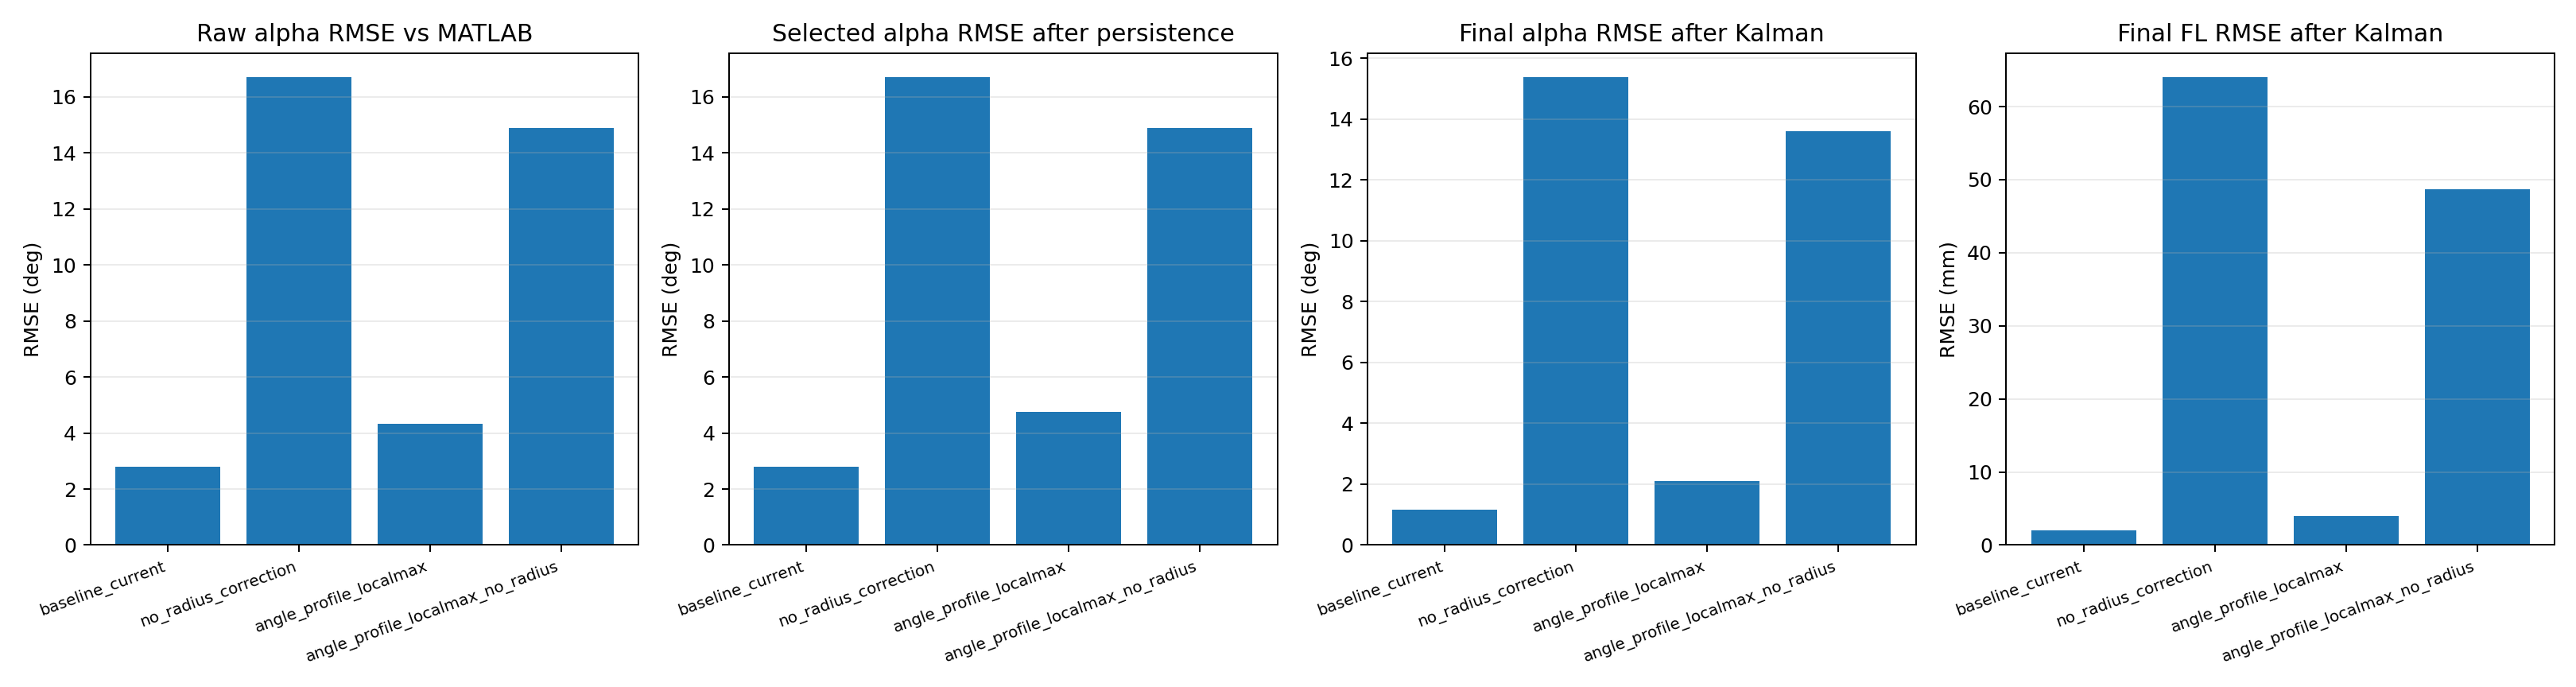

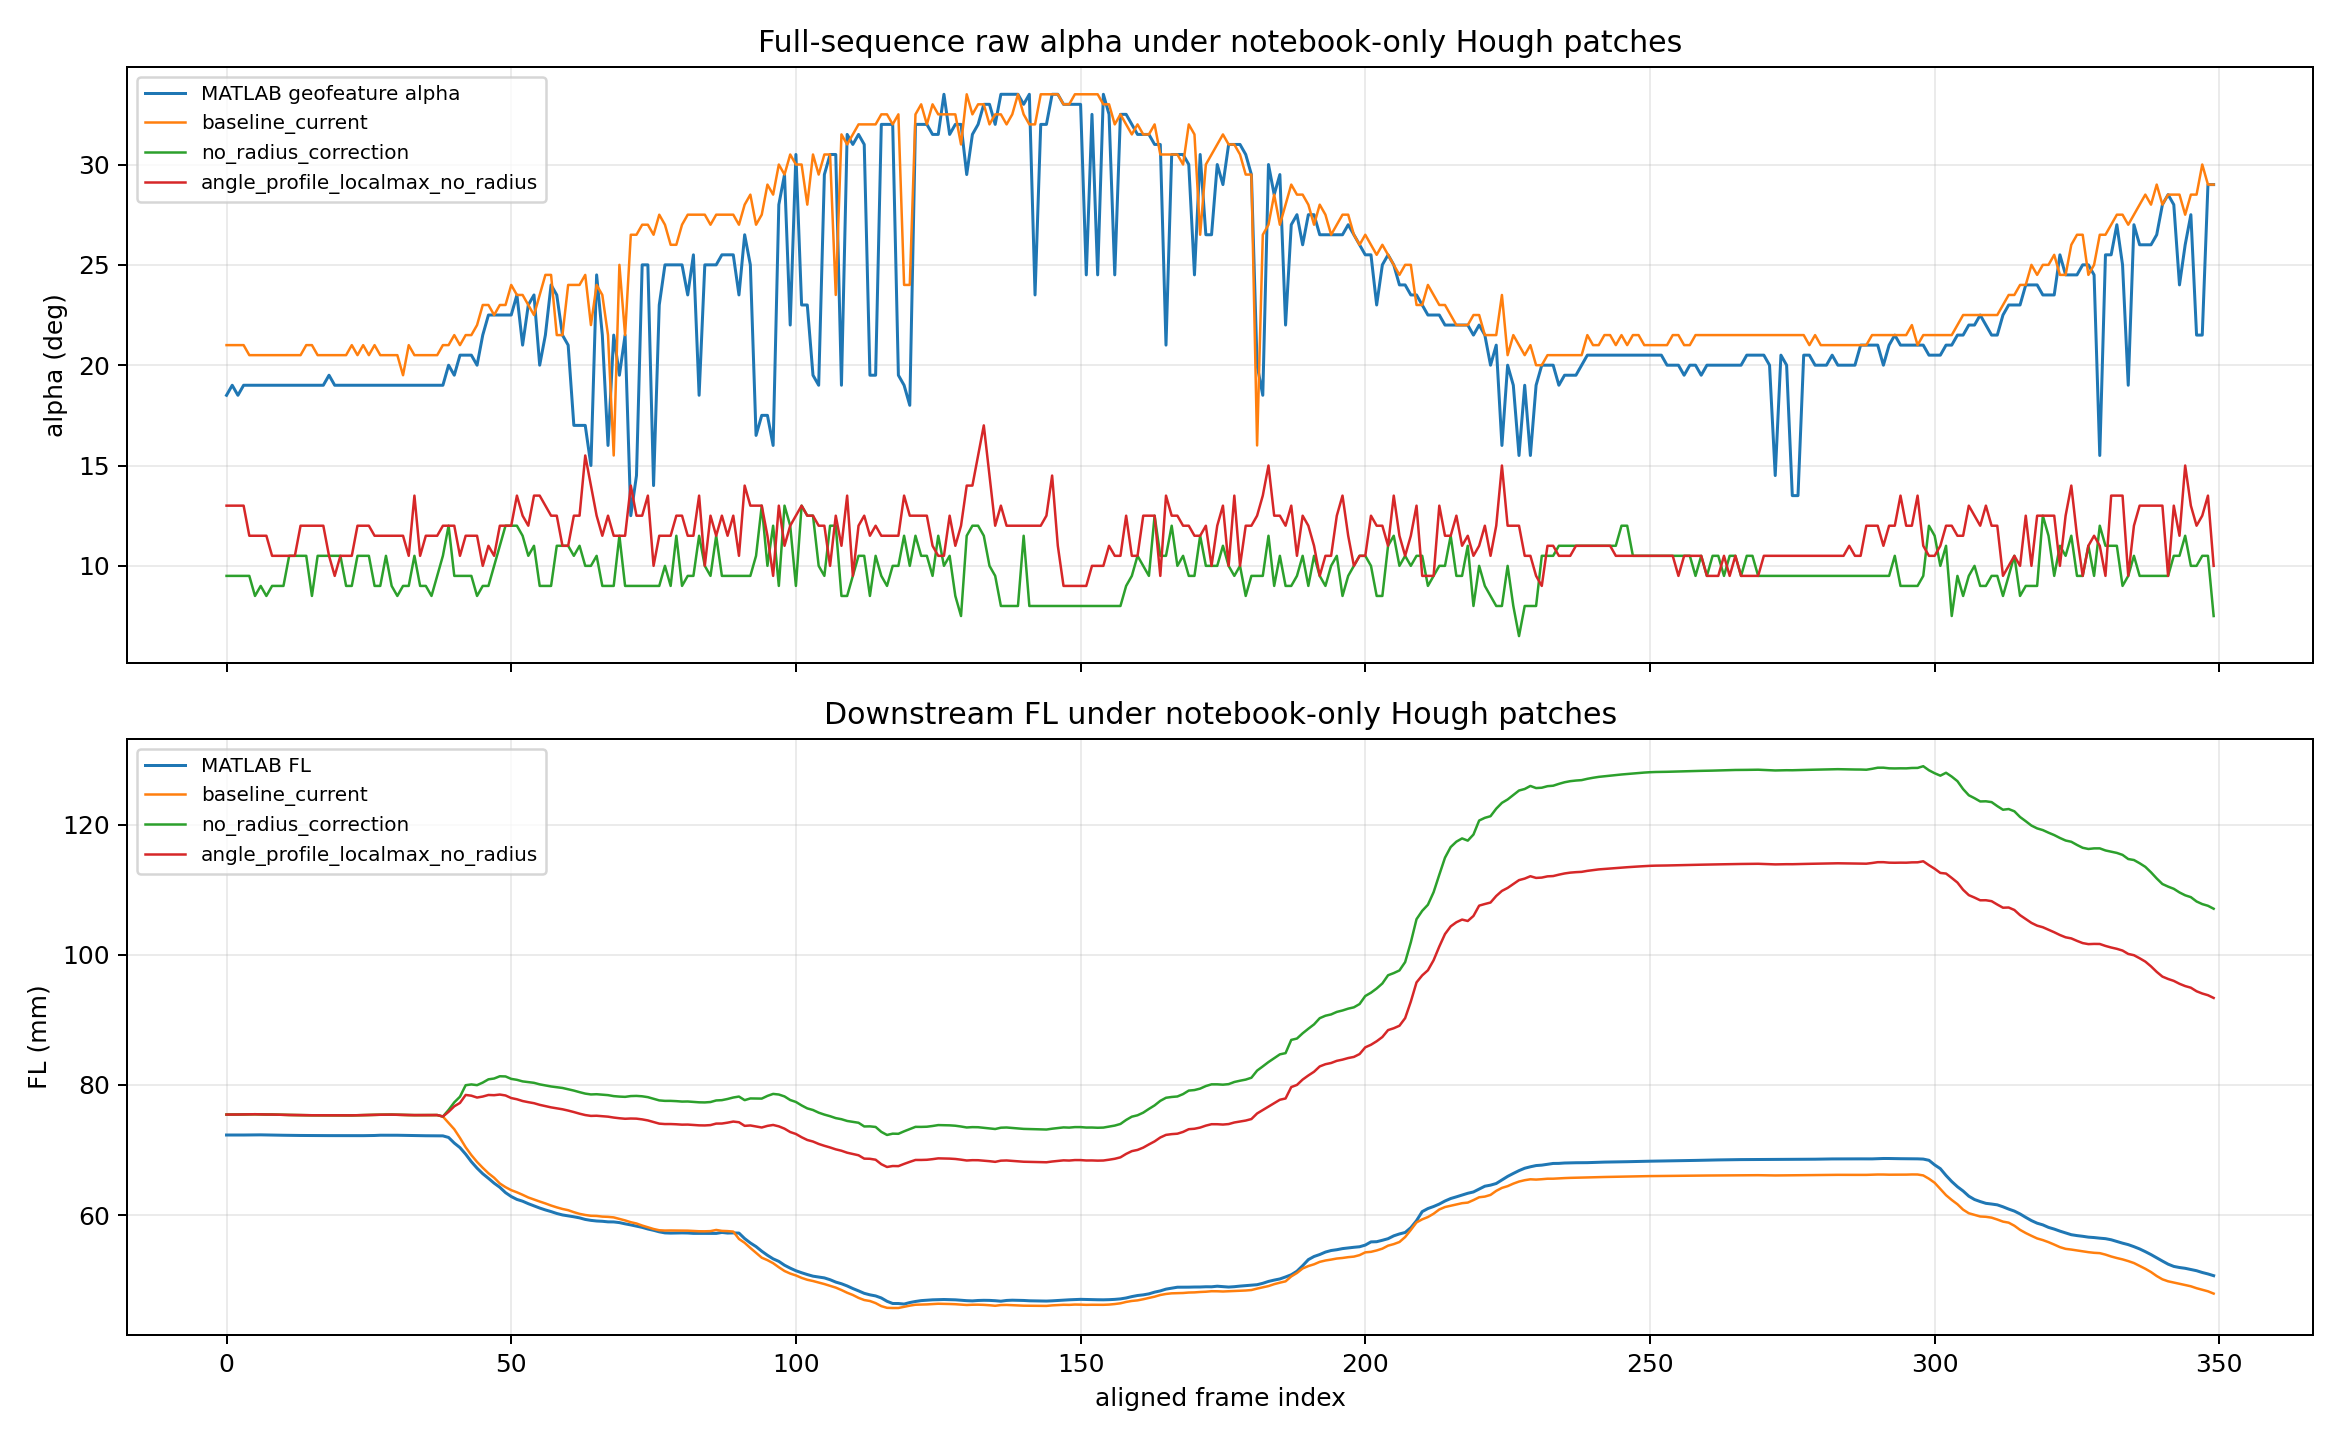

In [4]:
display(Image(filename=str(OUT / 'fullsequence_hough_patch_summary.png')))
display(Image(filename=str(OUT / 'fullsequence_hough_patch_traces.png')))